# Ablation E: MCN Graph Ablation

Isolates the contribution of the MCN graph structure by comparing three graph conditions
on the same model architecture, features, and split. All variants use the same
**transductive** MASST load (train+val+test nodes) as `spectral_classifier-hierarchical.ipynb`
and `ablation_a_masst_sweep.ipynb` -- message passing spans all nodes for both training
and eval, and the loss stays masked to training nodes only.

| Variant | Graph used | What it tests |
|---------|------------|---------------|
| **Full model (MCN)** | MWST from Leiden communities (transductive) | Our method |
| **Raw MASST graph** | Direct cosine-similarity edges (transductive) | Value of MCN processing (community detection + MWST) |
| **No graph** | No edges | Value of graph connectivity itself |


## 1. Imports

In [1]:
import os, csv, gc
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
import leidenalg
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import minimum_spanning_tree as _mst_func
from scipy.sparse import csr_matrix as _csr_mat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv
from torch_geometric.utils import dropout_edge
import warnings
warnings.filterwarnings('ignore')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')


C:\Users\bibhushaojha\AppData\Local\anaconda3\envs\torchgpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## 2. Configuration

In [2]:
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
mgf_path          = 'NIST/NIST_GC_EI_MAX_LIBRARY.mgf'
nist_classes_path = 'NIST/nist_classes.csv'
nist_dir          = 'C:/Users/bibhushaojha/Desktop/graph-based-spectral-classifier/NIST'
masst_tsv_path    = f'{nist_dir}/results_t50_e20.tsv'

use_4class = True
four_classes = [
    'Benzene and substituted derivatives',
    'Carboxylic acids and derivatives',
    'Fatty Acyls',
    'Organooxygen compounds',
]

leiden_seed     = 42
min_leiden_size = 10

random_state = 42; test_size = 0.20; val_size = 0.10

hidden = 128; num_layers = 2; num_heads = 4; dropout = 0.3; drop_edge_p = 0.1
epochs = 200; lr = 1e-3; patience = 20; w_sc = 0.3; w_cl = 0.7

print(f'MASST TSV exists: {os.path.exists(masst_tsv_path)}')


MASST TSV exists: True


## 3. Data Loading (run once)

In [3]:
def parse_mgf_file(path):
    entries, inside, meta, peaks = [], False, {}, []
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for raw in f:
            line = raw.strip()
            if not line: continue
            if line == 'BEGIN IONS': inside, meta, peaks = True, {}, []; continue
            if line == 'END IONS':
                if inside:
                    entries.append({'meta': meta.copy(),
                        'peaks': np.array(peaks, dtype=float) if peaks
                                 else np.empty((0,2), dtype=float)})
                inside, meta, peaks = False, {}, []; continue
            if not inside: continue
            if '=' in line: k, v = line.split('=',1); meta[k.strip()] = v.strip(); continue
            parts = line.split()
            if len(parts) >= 2:
                try: peaks.append([float(parts[0]), float(parts[1])])
                except ValueError: pass
    return entries

def read_nist_classes_csv(path):
    label_map = {}
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for row in csv.DictReader(f):
            sid = int(row['file'].strip())
            sk = row['Superklass'].strip(); k = row['klass'].strip()
            label_map[sid] = {
                'superclass': None if sk == 'null' else sk,
                'klass': None if (k == 'null' or k.startswith('subklass:')) else k,
            }
    return label_map

print('Loading MGF ...')
mgf_entries    = parse_mgf_file(mgf_path)
nist_label_map = read_nist_classes_csv(nist_classes_path)
dataset = []
for e in mgf_entries:
    scans = e['meta'].get('SCANS', '').strip()
    if not scans: continue
    try: sid = int(scans)
    except ValueError: continue
    lbl = nist_label_map.get(sid, {'superclass': None, 'klass': None})
    if lbl['superclass'] is None or lbl['klass'] is None: continue
    dataset.append({'scan_id': sid, 'peaks': e['peaks'],
                    'superclass': lbl['superclass'], 'klass': lbl['klass']})
if use_4class:
    dataset = [r for r in dataset if r['klass'] in four_classes]
print(f'Dataset: {len(dataset):,} spectra')


Loading MGF ...
Dataset: 84,692 spectra


## 4. Split & Spectral Features (run once)

In [4]:
all_idx = list(range(len(dataset))); all_labels = [r['klass'] for r in dataset]
lc = Counter(all_labels)
keep = [i for i in all_idx if lc[all_labels[i]] >= 2]
kl   = [all_labels[i] for i in keep]
tr_val, te_idx = train_test_split(keep, test_size=test_size, stratify=kl,
                                   random_state=random_state)
tr_idx, va_idx = train_test_split(tr_val,
    test_size=val_size/(1-test_size),
    stratify=[all_labels[i] for i in tr_val], random_state=random_state)
train_scan_ids = {dataset[i]['scan_id'] for i in tr_idx}
val_scan_ids   = {dataset[i]['scan_id'] for i in va_idx}
test_scan_ids  = {dataset[i]['scan_id'] for i in te_idx}
node_order_indices = sorted(r['scan_id'] for r in dataset)
scan_to_pos    = {sid: i for i, sid in enumerate(node_order_indices)}
scan_to_ds_idx = {r['scan_id']: i for i, r in enumerate(dataset)}
n_nodes        = len(node_order_indices)

def peaks_to_features(peaks, top_k=20):
    n_out = top_k * 17
    if peaks is None or len(peaks) == 0: return np.zeros(n_out, dtype=np.float32)
    p = peaks.astype(np.float32)
    p = p[np.argsort(p[:,1])[::-1][:top_k]]
    if len(p) < top_k:
        p = np.vstack([p, np.zeros((top_k-len(p), 2), dtype=np.float32)])
    mz, inten = p[:,0], p[:,1]; inten = inten / max(inten.max(), 1e-6)
    wl  = np.logspace(-1, 3, num=8, dtype=np.float32)
    ang = (2*np.pi*mz[:,None]) / wl[None,:]
    enc = np.empty((top_k, 16), dtype=np.float32)
    enc[:,0::2] = np.sin(ang); enc[:,1::2] = np.cos(ang)
    return np.concatenate([enc, inten[:,None]], axis=1).flatten()

raw_x = np.stack([peaks_to_features(dataset[scan_to_ds_idx[sid]]['peaks'])
                  for sid in node_order_indices], axis=0).astype(np.float32)
tr_rows   = np.array([scan_to_pos[s] for s in train_scan_ids])
feat_mean = raw_x[tr_rows].mean(0, keepdims=True)
feat_std  = raw_x[tr_rows].std(0,  keepdims=True).clip(min=1e-6)
x_spec    = ((raw_x - feat_mean) / feat_std).astype(np.float32)
print(f'train={len(train_scan_ids):,}  val={len(val_scan_ids):,}  test={len(test_scan_ids):,}')
print(f'x_spec: {x_spec.shape}')


train=59,283  val=8,470  test=16,939
x_spec: (84692, 340)


## 5. Labels & Masks (run once)

In [5]:
le_sc = LabelEncoder().fit(sorted(set(r['superclass'] for r in dataset)))
le_cl = LabelEncoder().fit(sorted(set(r['klass']      for r in dataset)))
n_sc  = len(le_sc.classes_); n_cl = len(le_cl.classes_)
y_sc_dev = torch.tensor(
    [int(le_sc.transform([dataset[scan_to_ds_idx[sid]]['superclass']])[0])
     for sid in node_order_indices], dtype=torch.long).to(device)
y_cl_dev = torch.tensor(
    [int(le_cl.transform([dataset[scan_to_ds_idx[sid]]['klass']])[0])
     for sid in node_order_indices], dtype=torch.long).to(device)

def make_mask(scan_ids):
    m = torch.zeros(n_nodes, dtype=torch.bool)
    for i, sid in enumerate(node_order_indices):
        if sid in scan_ids: m[i] = True
    return m
train_mask     = make_mask(train_scan_ids)
val_mask       = make_mask(val_scan_ids)
test_mask      = make_mask(test_scan_ids)
train_mask_dev = train_mask.to(device)
val_mask_dev   = val_mask.to(device)
test_mask_dev  = test_mask.to(device)

sc_to_cl_mask = torch.zeros(n_sc, n_cl, dtype=torch.bool)
for r in dataset:
    sc_to_cl_mask[
        int(le_sc.transform([r['superclass']])[0]),
        int(le_cl.transform([r['klass']])[0])] = True
sc_to_cl_mask_dev = sc_to_cl_mask.to(device)

def make_wts(y, mask, n):
    c = np.bincount(y[mask].cpu().numpy(), minlength=n).astype(float)
    w = 1.0 / c.clip(min=1)
    return torch.tensor((w / w.sum() * n).astype(np.float32)).to(device)
sc_wts = make_wts(y_sc_dev, train_mask_dev, n_sc)
cl_wts = make_wts(y_cl_dev, train_mask_dev, n_cl)
print(f'n_sc={n_sc}  n_cl={n_cl}')


n_sc=4  n_cl=4


## 6. Build Transductive Graphs (MCN / Raw MASST / No graph)

All three graph variants are built from a single transductive MASST load (train+val+test
nodes), matching `build_transductive_mcn` in `ablation_a_masst_sweep.ipynb` and
`spectral_classifier-hierarchical.ipynb`. This ablation now isolates graph **topology**
as the variable, instead of conflating it with the old train-only / self-loop-eval regime:

- **Full model (MCN)**: Leiden communities on every connected component -> per-community
  Maximum Weight Spanning Tree, over all nodes -- the identical edge construction used by
  the hierarchical notebook.
- **Raw MASST graph**: every cosine-similarity edge from the same transductive load, no
  MWST reduction. Community features are computed from the same Leiden run as the MCN
  variant, so only the edge topology differs between the two.
- **No graph**: spectral features only (340-dim; no community features are possible
  without a graph), zero edges.

In all cases the same graph is used for training and evaluation (transductive); the loss
stays masked to training nodes only, so labels are never shared.


In [6]:
def build_transductive_graphs(masst_tsv_path, scan_to_pos, x_spec, node_order_indices, n_nodes,
                               min_leiden_size=10, leiden_seed=42):
    """Build all graph variants for Ablation E from ONE transductive MASST load.

    Uses the same transductive construction as build_transductive_mcn in
    ablation_a_masst_sweep.ipynb / spectral_classifier-hierarchical.ipynb: MASST cosine
    edges over ALL nodes (train+val+test) -> Leiden community detection on every
    connected component -> per-community Maximum Weight Spanning Tree. Both the MCN
    (MWST) and the raw MASST (every edge, no reduction) variants are derived from that
    SAME graph and SAME Leiden communities, so community features are identical between
    them and only the edge topology differs -- matching the original ablation_e design
    intent, now leakage-free and covering all nodes for both training and eval.

    Returns
    -------
    x_aug_dev : (n_nodes, 344) spectral + community features, on device
    mcn_ei/ea : bidirectional MWST edge tensors (Full model (MCN) variant), on device
    raw_ei/ea : bidirectional raw MASST edge tensors (Raw MASST graph variant), on device
    info      : dict of diagnostics
    """
    all_scan_ids = set(scan_to_pos)

    # 1. Load MASST cosine edges over ALL nodes (shared by both graph variants)
    pairs = []
    for chunk in pd.read_csv(
            masst_tsv_path, sep='\t',
            usecols=['scan_1', 'scan_2', 'dot_product_shifted'],
            dtype={'scan_1': np.int64, 'scan_2': np.int64, 'dot_product_shifted': np.float32},
            chunksize=500_000):
        chunk = chunk[chunk['scan_1'] != chunk['scan_2']]
        chunk = chunk[chunk['scan_1'].isin(all_scan_ids) & chunk['scan_2'].isin(all_scan_ids)]
        if len(chunk) == 0:
            continue
        u = chunk['scan_1'].map(scan_to_pos).to_numpy()
        v = chunk['scan_2'].map(scan_to_pos).to_numpy()
        pairs.append(np.column_stack([np.minimum(u, v), np.maximum(u, v),
                                      chunk['dot_product_shifted'].to_numpy()]))

    allp = np.concatenate(pairs, axis=0) if pairs else np.zeros((0, 3), dtype=np.float32)
    edf  = pd.DataFrame({'u': allp[:, 0].astype(np.int64),
                         'v': allp[:, 1].astype(np.int64),
                         'cosine_score': allp[:, 2].astype(np.float32)})
    edf  = edf.groupby(['u', 'v'], as_index=False)['cosine_score'].max()

    G = nx.from_pandas_edgelist(edf, 'u', 'v', edge_attr='cosine_score')
    G.add_nodes_from(range(n_nodes))
    print(f'MASST graph (all nodes): {G.number_of_nodes():,} nodes  {G.number_of_edges():,} edges')

    # 2. Leiden community detection on every connected component
    all_components = sorted(nx.connected_components(G), key=len, reverse=True)
    mcn_pos_to_comm = {}
    next_comm_id    = 0
    for comp_nodes in all_components:
        size = len(comp_nodes)
        if size == 1:
            node = list(comp_nodes)[0]
            mcn_pos_to_comm[node] = next_comm_id
            next_comm_id += 1
        elif size < min_leiden_size:
            for node in comp_nodes:
                mcn_pos_to_comm[node] = next_comm_id
            next_comm_id += 1
        else:
            comp_nodes_sorted = sorted(comp_nodes)
            local_remap       = {old: new for new, old in enumerate(comp_nodes_sorted)}
            subgraph          = G.subgraph(comp_nodes_sorted)
            ig_comp = ig.Graph(n=size, directed=False)
            ig_comp.add_edges([(local_remap[u], local_remap[v]) for u, v in subgraph.edges()])
            ig_comp.es['weight'] = [subgraph.edges[u, v]['cosine_score'] for u, v in subgraph.edges()]
            part = leidenalg.find_partition(
                ig_comp, leidenalg.ModularityVertexPartition,
                weights='weight', seed=leiden_seed)
            for local_i, mcn_pos in enumerate(comp_nodes_sorted):
                mcn_pos_to_comm[mcn_pos] = next_comm_id + int(part.membership[local_i])
            next_comm_id += len(part)
    n_communities = next_comm_id
    singleton_nodes = {node for node in G.nodes() if G.degree(node) == 0}
    print(f'Communities: {n_communities:,}  Singletons: {len(singleton_nodes):,}')

    # 3. Maximum Weight Spanning Tree per community (MCN edge set)
    comm_to_nodes = defaultdict(list)
    for mcn_pos, comm_id in mcn_pos_to_comm.items():
        comm_to_nodes[comm_id].append(mcn_pos)
    mst_edges = []
    for cid in range(n_communities):
        members = comm_to_nodes[cid]
        if len(members) <= 1:
            continue
        local_idx       = {mcn_pos: i for i, mcn_pos in enumerate(members)}
        n_c             = len(members)
        rows, cols, wts = [], [], []
        for u in members:
            for v in G.neighbors(u):
                if mcn_pos_to_comm.get(v) == cid and v in local_idx:
                    rows.append(local_idx[u])
                    cols.append(local_idx[v])
                    wts.append(G.edges[u, v]['cosine_score'])
        if not rows:
            continue
        mat = _csr_mat((np.array(wts, dtype=np.float32), (rows, cols)), shape=(n_c, n_c))
        neg = mat.copy(); neg.data *= -1
        mst = _mst_func(neg).tocoo(); mst.data *= -1
        for r, c, w in zip(mst.row, mst.col, mst.data):
            mst_edges.append((members[r], members[c], float(w)))
    print(f'MCN (MWST): {len(mst_edges):,} edges')

    # 4. Raw MASST edge set: every edge in G, no reduction
    raw_edges = [(u, v, G.edges[u, v]['cosine_score']) for u, v in G.edges()]
    print(f'Raw MASST: {len(raw_edges):,} edges')

    def to_bidirectional(edge_list):
        if not edge_list:
            return (torch.zeros((2, 0), dtype=torch.long, device=device),
                    torch.zeros((0, 1), dtype=torch.float32, device=device))
        src = [u for u, v, w in edge_list]; dst = [v for u, v, w in edge_list]
        wts = [w for u, v, w in edge_list]
        ei  = torch.tensor([src + dst, dst + src], dtype=torch.long, device=device)
        ea  = torch.tensor(wts + wts, dtype=torch.float32, device=device).unsqueeze(1)
        return ei, ea

    mcn_ei, mcn_ea = to_bidirectional(mst_edges)
    raw_ei, raw_ea = to_bidirectional(raw_edges)

    # 5. Community features for ALL nodes (transductive; shared by MCN and Raw MASST)
    node_comm_id   = np.array([mcn_pos_to_comm[i] for i in range(n_nodes)], dtype=np.int64)
    comm_sizes_arr = np.bincount(node_comm_id, minlength=n_communities)
    comm_centroids = np.zeros((n_communities, x_spec.shape[1]), dtype=np.float32)
    np.add.at(comm_centroids, node_comm_id, x_spec)
    comm_centroids /= np.maximum(comm_sizes_arr[:, None], 1)
    f_log_size = np.log1p(comm_sizes_arr[node_comm_id]).astype(np.float32)
    degree_arr    = np.array([G.degree(i) for i in range(n_nodes)], dtype=np.float32)
    size_m1       = np.maximum(comm_sizes_arr[node_comm_id] - 1, 1).astype(np.float32)
    f_degree_cent = (degree_arr / size_m1).clip(0, 1)
    diffs       = x_spec - comm_centroids[node_comm_id]
    f_dist_cent = np.linalg.norm(diffs, axis=1).astype(np.float32)
    f_singleton = np.array([1.0 if i in singleton_nodes else 0.0 for i in range(n_nodes)],
                           dtype=np.float32)
    comm_features = np.stack([f_log_size, f_degree_cent, f_dist_cent, f_singleton], axis=1).astype(np.float32)
    x_aug = np.concatenate([x_spec, comm_features], axis=1).astype(np.float32)
    x_aug_dev = torch.tensor(x_aug, dtype=torch.float32).to(device)

    info = {
        'n_edges_masst': G.number_of_edges(), 'n_communities': n_communities,
        'n_mst_edges': len(mst_edges), 'n_singletons': len(singleton_nodes),
    }
    return x_aug_dev, mcn_ei, mcn_ea, raw_ei, raw_ea, info


print('Building transductive graphs (MCN / Raw MASST) ...')
x_aug_dev, mcn_ei, mcn_ea, raw_ei, raw_ea, graph_info = build_transductive_graphs(
    masst_tsv_path, scan_to_pos, x_spec, node_order_indices, n_nodes,
    min_leiden_size=min_leiden_size, leiden_seed=leiden_seed)

# Full model (MCN): same graph for training and eval (transductive), loss masked to train
ei_tr_mcn, ea_tr_mcn = mcn_ei, mcn_ea
ei_ev_mcn, ea_ev_mcn = mcn_ei, mcn_ea

# Raw MASST graph: same community features as MCN, but every cosine edge (no MWST reduction)
ei_tr_raw, ea_tr_raw = raw_ei, raw_ea
ei_ev_raw, ea_ev_raw = raw_ei, raw_ea

# No graph: spectral features only (no community features possible without a graph), zero edges
x_spec_dev = torch.tensor(x_spec, dtype=torch.float32).to(device)
ei_tr_none = torch.zeros((2,0), dtype=torch.long, device=device)
ea_tr_none = torch.zeros((0,1), dtype=torch.float32, device=device)
ei_ev_none = torch.zeros((2,0), dtype=torch.long, device=device)
ea_ev_none = torch.zeros((0,1), dtype=torch.float32, device=device)

print(f'MCN        : x={x_aug_dev.shape}  edges={ei_tr_mcn.shape[1]:,}')
print(f'Raw MASST  : x={x_aug_dev.shape}  edges={ei_tr_raw.shape[1]:,}')
print(f'No graph   : x={x_spec_dev.shape}  edges=0')


Building transductive graphs (MCN / Raw MASST) ...
MASST graph (all nodes): 84,692 nodes  888,192 edges
Communities: 9,087  Singletons: 357
MCN (MWST): 75,600 edges
Raw MASST: 888,192 edges
MCN        : x=torch.Size([84692, 344])  edges=151,200
Raw MASST  : x=torch.Size([84692, 344])  edges=1,776,384
No graph   : x=torch.Size([84692, 340])  edges=0


## 7. Model

In [7]:
class SpecGNNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, num_heads=4, dropout=0.3, drop_edge_p=0.1):
        super().__init__()
        assert out_ch % num_heads == 0; self.drop_edge_p = drop_edge_p
        self.conv = GATConv(in_ch, out_ch//num_heads, heads=num_heads,
                            concat=True, dropout=dropout,
                            edge_dim=1, add_self_loops=False)
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch)
        self.act  = nn.GELU(); self.drop = nn.Dropout(dropout)

    def forward(self, x, ei, ea, training=False):
        if training and self.drop_edge_p > 0 and ei.shape[1] > 0:
            ei, mask = dropout_edge(ei, p=self.drop_edge_p,
                                    force_undirected=True, training=True)
            ea = ea[mask]
        if ei.shape[1] == 0:
            # No edges: skip message passing, apply residual only
            return self.norm(self.drop(self.act(self.res(x))) + self.res(x))
        return self.norm(self.drop(self.act(self.conv(x, ei, edge_attr=ea))) + self.res(x))


class HierarchicalSpecGNN(nn.Module):
    def __init__(self, feat_dim=344, hidden=128, num_layers=2, num_heads=4,
                 n_superclass=4, n_class=4, dropout=0.3, drop_edge_p=0.1):
        super().__init__()
        self.norm_in = nn.LayerNorm(feat_dim)
        self.proj    = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout))
        self.layers  = nn.ModuleList([
            SpecGNNBlock(hidden, hidden, num_heads, dropout, drop_edge_p)
            for _ in range(num_layers)])
        self.jk      = nn.Sequential(
            nn.Linear(hidden*(num_layers+1), hidden), nn.LayerNorm(hidden), nn.GELU())
        self.sc_head = nn.Sequential(
            nn.Linear(hidden, hidden//2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden//2, n_superclass))
        self.cl_head = nn.Sequential(
            nn.Linear(hidden, hidden//2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden//2, n_class))

    def encode(self, x, ei, ea, training=False):
        h = self.proj(self.norm_in(x)); hs = [h]
        for layer in self.layers: h = layer(h, ei, ea, training); hs.append(h)
        return self.jk(torch.cat(hs, dim=-1))

    def forward(self, x, ei, ea, training=False):
        emb = self.encode(x, ei, ea, training)
        return self.sc_head(emb), self.cl_head(emb)

    def predict(self, x, ei, ea, sc_mask):
        self.eval()
        with torch.no_grad():
            sc_lg, cl_lg = self.forward(x, ei, ea)
            cl_lg = cl_lg.masked_fill(~sc_mask[sc_lg.argmax(1)], float('-inf'))
        return sc_lg, cl_lg

print('HierarchicalSpecGNN defined.')


HierarchicalSpecGNN defined.


## 8. Training Function

In [8]:
def run_variant(name, x_dev, ei_tr, ea_tr, ei_ev, ea_ev):
    print(f'\n{"="*60}')
    print(f'Variant : {name}')
    print(f'  feat_dim={x_dev.shape[1]}  ei_train={ei_tr.shape[1]:,}  ei_eval={ei_ev.shape[1]:,}')

    model = HierarchicalSpecGNN(
        feat_dim=x_dev.shape[1], hidden=hidden, num_layers=num_layers,
        num_heads=num_heads, n_superclass=n_sc, n_class=n_cl,
        dropout=dropout, drop_edge_p=drop_edge_p).to(device)
    print(f'  Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='max', factor=0.5, patience=10, min_lr=1e-6)
    crit_sc = nn.CrossEntropyLoss(weight=sc_wts)
    crit_cl = nn.CrossEntropyLoss(weight=cl_wts)
    best_val_f1=0.0; best_state=None; best_ep=0; es_ctr=0; curve=[]

    for epoch in range(1, epochs+1):
        model.train(); opt.zero_grad()
        sc_lg, cl_lg = model(x_dev, ei_tr, ea_tr, training=True)
        loss = (w_sc * crit_sc(sc_lg[train_mask_dev], y_sc_dev[train_mask_dev])
              + w_cl * crit_cl(cl_lg[train_mask_dev], y_cl_dev[train_mask_dev]))
        loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        model.eval()
        with torch.no_grad():
            sc_lg, cl_lgm = model.predict(x_dev, ei_ev, ea_ev, sc_to_cl_mask_dev)
            val_f1 = f1_score(y_cl_dev[val_mask_dev].cpu(),
                              cl_lgm[val_mask_dev].argmax(1).cpu(),
                              average='macro', zero_division=0)
        sched.step(val_f1); curve.append(val_f1)
        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1=val_f1; best_ep=epoch; es_ctr=0
            best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
        else: es_ctr += 1
        if es_ctr >= patience: print(f'  Early stop ep={epoch}'); break

    model.load_state_dict({k:v.to(device) for k,v in best_state.items()})
    model.eval()
    with torch.no_grad():
        sc_lg, cl_lgm = model.predict(x_dev, ei_ev, ea_ev, sc_to_cl_mask_dev)

    def _m(mask):
        sp=sc_lg[mask].argmax(1).cpu().numpy(); st=y_sc_dev[mask].cpu().numpy()
        cp=cl_lgm[mask].argmax(1).cpu().numpy(); ct=y_cl_dev[mask].cpu().numpy()
        return {'sc_acc': round((sp==st).mean()*100,2),
                'sc_f1':  round(f1_score(st,sp,average='macro',zero_division=0),4),
                'cl_acc': round((cp==ct).mean()*100,2),
                'cl_f1':  round(f1_score(ct,cp,average='macro',zero_division=0),4)}

    va=_m(val_mask_dev); te=_m(test_mask_dev)
    print(f'  Val  -> SC F1={va["sc_f1"]}  CL F1={va["cl_f1"]}')
    print(f'  Test -> SC acc={te["sc_acc"]}%  SC F1={te["sc_f1"]}  '
          f'CL acc={te["cl_acc"]}%  CL F1={te["cl_f1"]}')
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {**te, 'val_sc_f1': va['sc_f1'], 'val_cl_f1': va['cl_f1'],
            'best_ep': best_ep, 'val_cl_f1_curve': curve}

print('run_variant() defined.')


run_variant() defined.


## 9. Run All Three Variants

In [9]:
results = {}

results['Full model (MCN)'] = run_variant(
    'Full model (MCN)', x_aug_dev, ei_tr_mcn, ea_tr_mcn, ei_ev_mcn, ea_ev_mcn)

results['Raw MASST graph'] = run_variant(
    'Raw MASST graph', x_aug_dev, ei_tr_raw, ea_tr_raw, ei_ev_raw, ea_ev_raw)

results['No graph'] = run_variant(
    'No graph', x_spec_dev, ei_tr_none, ea_tr_none, ei_ev_none, ea_ev_none)

print('\nAll variants complete.')



Variant : Full model (MCN)
  feat_dim=344  ei_train=151,200  ei_eval=151,200
  Params: 146,232
  Early stop ep=136
  Val  -> SC F1=0.5765  CL F1=0.5765
  Test -> SC acc=61.82%  SC F1=0.5519  CL acc=61.82%  CL F1=0.5519

Variant : Raw MASST graph
  feat_dim=344  ei_train=1,776,384  ei_eval=1,776,384
  Params: 146,232
  Early stop ep=123
  Val  -> SC F1=0.612  CL F1=0.612
  Test -> SC acc=65.65%  SC F1=0.5952  CL acc=65.65%  CL F1=0.5952

Variant : No graph
  feat_dim=340  ei_train=0  ei_eval=0
  Params: 145,712
  Early stop ep=182
  Val  -> SC F1=0.5662  CL F1=0.5662
  Test -> SC acc=60.51%  SC F1=0.5457  CL acc=60.51%  CL F1=0.5457

All variants complete.


## 10. Results Table

In [10]:
rows = []
full_cl_f1 = results['Full model (MCN)']['cl_f1']
for name, m in results.items():
    delta = m['cl_f1'] - full_cl_f1
    rows.append({
        'Variant': name,
        'Graph edges': {
            'Full model (MCN)': f'{ei_tr_mcn.shape[1]:,} (MWST)',
            'Raw MASST graph':  f'{ei_tr_raw.shape[1]:,} (all)',
            'No graph':         '0',
        }[name],
        'Val SC F1': m['val_sc_f1'], 'Val CL F1': m['val_cl_f1'],
        'Test SC F1': m['sc_f1'], 'Test CL Acc': m['cl_acc'],
        'Test CL F1': m['cl_f1'],
        'Delta CL F1': f'{delta:+.4f}',
        'Best Epoch': m['best_ep'],
    })
df = pd.DataFrame(rows)
print('MCN Graph Ablation Results:')
print(df.to_string(index=False))
df.to_csv(os.path.join(RESULTS_DIR, 'ablation_e_results.csv'), index=False)
print('Saved: ablation_e_results.csv')


MCN Graph Ablation Results:
         Variant     Graph edges  Val SC F1  Val CL F1  Test SC F1  Test CL Acc  Test CL F1 Delta CL F1  Best Epoch
Full model (MCN)  151,200 (MWST)     0.5765     0.5765      0.5519        61.82      0.5519     +0.0000         116
 Raw MASST graph 1,776,384 (all)     0.6120     0.6120      0.5952        65.65      0.5952     +0.0433         103
        No graph               0     0.5662     0.5662      0.5457        60.51      0.5457     -0.0062         162
Saved: ablation_e_results.csv


## 11. Visualization

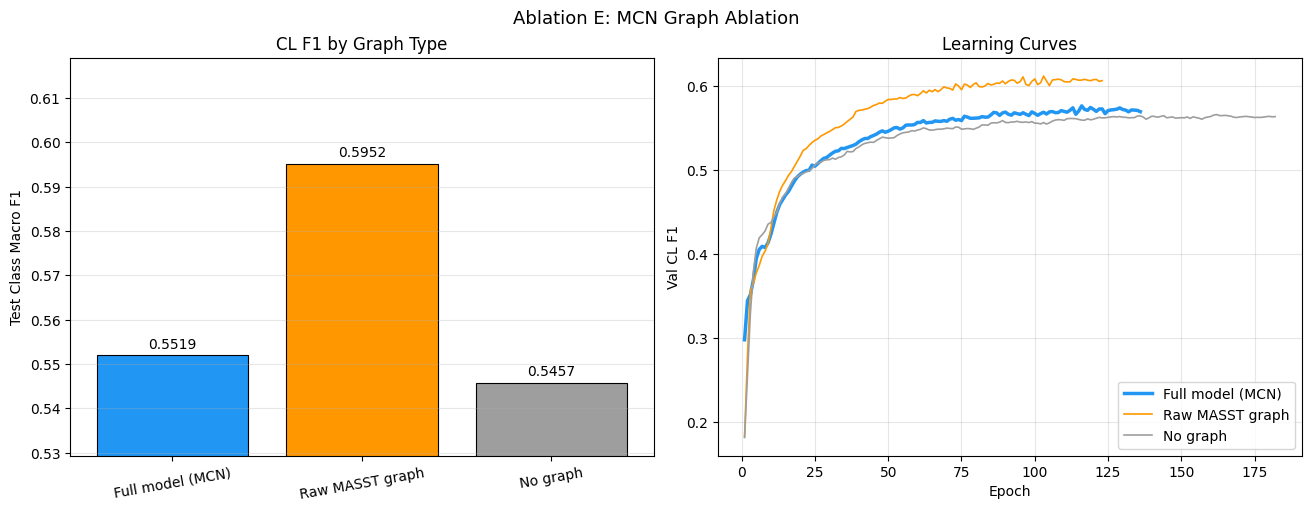

Saved: ablation_e_results.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle('Ablation E: MCN Graph Ablation', fontsize=13)

variants = list(results.keys())
cl_f1s   = [results[v]['cl_f1'] for v in variants]
colors   = ['#2196F3', '#FF9800', '#9E9E9E']

ax = axes[0]
bars = ax.bar(variants, cl_f1s, color=colors, edgecolor='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax.set_ylabel('Test Class Macro F1')
ax.set_title('CL F1 by Graph Type')
ax.set_ylim(min(cl_f1s)*0.97, max(cl_f1s)*1.04)
ax.tick_params(axis='x', rotation=10)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
for v, col in zip(variants, colors):
    curve = results[v]['val_cl_f1_curve']
    lw = 2.5 if 'MCN' in v else 1.2
    ax.plot(range(1, len(curve)+1), curve, label=v, color=col, linewidth=lw)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val CL F1')
ax.set_title('Learning Curves'); ax.legend(); ax.grid(alpha=0.3)

plt.savefig(os.path.join(RESULTS_DIR, 'ablation_e_results.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved: ablation_e_results.png')
